In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.9 MB/s eta 0:00:00


In [4]:
import zipfile
import os

# Corrected path: the archive.zip is in /content/, not in Google Drive
zip_path = "/content/archive.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [5]:
import os

for root, dirs, files in os.walk("/content/dataset"):
    print(root)
    if len(files) > 0:
        print("Files:", files[:5])

/content/dataset
/content/dataset/results_yolov8n_100e
/content/dataset/results_yolov8n_100e/kaggle
/content/dataset/results_yolov8n_100e/kaggle/working
Files: ['__notebook__.ipynb', 'ppe_data.yaml', 'yolov8n.pt']
/content/dataset/results_yolov8n_100e/kaggle/working/runs
/content/dataset/results_yolov8n_100e/kaggle/working/runs/detect
/content/dataset/results_yolov8n_100e/kaggle/working/runs/detect/train
Files: ['labels.jpg', 'F1_curve.png', 'confusion_matrix.png', 'P_curve.png', 'labels_correlogram.jpg']
/content/dataset/results_yolov8n_100e/kaggle/working/runs/detect/train/weights
Files: ['best.pt', 'last.pt']
/content/dataset/source_files
/content/dataset/source_files/source_files
Files: ['schupan_japan1web.jpg', 'construction-safety.jpg', 'portrait-of-woman-with-mask-and-man-with-safety-glasses-on-a-construction-HX01FH.jpg', 'JapanPPE.mp4', 'two-young-construction-workers-wearing-555864.jpg']
/content/dataset/css-data
Files: ['README.dataset.txt', 'README.roboflow.txt']
/content/da

In [6]:
%%writefile /content/ppe.yaml

path: /content/dataset/css-data

train: train/images
val: valid/images
test: test/images

names:
  0: Hardhat
  1: Mask
  2: NO-Hardhat
  3: NO-Mask
  4: NO-Safety Vest
  5: Person
  6: Safety Cone
  7: Safety Vest
  8: machinery
  9: vehicle

Writing /content/ppe.yaml


In [7]:
from ultralytics import YOLO

print("Dataset configuration created successfully.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Dataset configuration created successfully.


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="/content/ppe.yaml",
    epochs=50,
    imgsz=640,
    batch=16
)

Ultralytics 8.4.64 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ppe.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective

In [ ]:
metrics = model.val()

print(metrics)

NameError: name 'model' is not defined

In [ ]:
results = model.predict(
    source="/content/dataset/css-data/test/images",
    conf=0.25,
    save=True
)

NameError: name 'model' is not defined

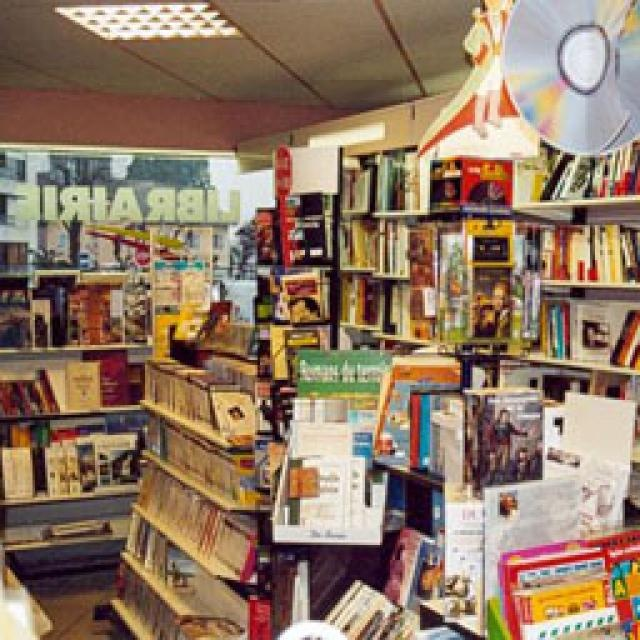

In [ ]:
from IPython.display import Image, display
import glob

result_images = glob.glob("/content/runs/detect/predict/*.jpg")

display(Image(filename=result_images[0]))

In [ ]:
import shutil

shutil.copy(
    "/content/runs/detect/train/weights/best.pt",
    "/content/drive/MyDrive/best.pt"
)

print("Model saved to Google Drive!")

Model saved to Google Drive!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving h.avif to h.avif


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/best.pt")

results = model.predict(
    source=list(uploaded.keys())[0],
    conf=0.25,
    save=True
)


image 1/1 /content/h.avif: 640x640 1 Hardhat, 1 Person, 7.2ms
Speed: 2.8ms preprocess, 7.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-2


In [ ]:
from IPython.display import Image, display
import glob
import os

prediction_output_dir = "/content/runs/detect/predict-2"

# List all files in the directory to check their extensions
all_files_in_dir = os.listdir(prediction_output_dir)
print(f"Files found in {prediction_output_dir}: {all_files_in_dir}")

# Try to find common image extensions, or just pick the first one if there's only one
predicted_images = []
for ext in ['.jpg', '.png', '.jpeg', '.avif']:
    predicted_images.extend(glob.glob(os.path.join(prediction_output_dir, f"*{ext}")))

if predicted_images:
    # Display the last found image, assuming it's the most recent prediction
    display(Image(filename=predicted_images[-1]))
else:
    print(f"No predicted images found in {prediction_output_dir} with common extensions. Please ensure the prediction ran successfully and saved images.")


FileNotFoundError: [Errno 2] No such file or directory: '/content/runs/detect/predict-2'